### Importing all the necessary libraries and prerequisites

In [618]:
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import chi2
from arch import arch_model
import seaborn as sns
import yfinance
import warnings
warnings.filterwarnings("ignore")
sns.set()

### ***WORKING ON SENSEX STOCK INDEX***

#### **---Importing data---**

In [619]:
raw_sensex_data=pd.read_csv('BSE_Sensex_30_Historical_Data.csv')
raw_sensex_data.tail()

,Date,Price,Open,High,Low,Vol.
4049,01/08/2010,"17,540.29","17,603.87","17,658.12","17,508.96",17.30M
4050,01/07/2010,"17,615.72","17,701.97","17,733.34","17,566.54",17.96M
4051,01/06/2010,"17,701.13","17,719.47","17,790.33","17,636.71",21.46M
4052,01/05/2010,"17,686.24","17,555.77","17,729.78","17,555.77",27.00M
4053,01/04/2010,"17,558.73","17,473.45","17,582.84","17,378.38",28.18M


In [620]:
# making a copy of our data
df_sensex=raw_sensex_data.copy()
df_sensex.describe()

,Date,Price,Open,High,Low,Vol.
count,4054,4054,4054,4054,4054,4054
unique,4054,4054,4046,4052,4053,1800
top,01/04/2010,"17,558.73","65,503.85","28,143.28","25,769.81",9.91M
freq,1,1,2,2,2,10


### *As we can see our data is stored in string so we have to chang its data type*

In [621]:
# Remove commas and convert to numeric
cols = ['Price', 'Open', 'High', 'Low']
for col in cols:
    df_sensex[col] = df_sensex[col].str.replace(',', '').astype(float)

# Now describe() will show mean, std, quantiles etc.
df_sensex.describe()

,Price,Open,High,Low
count,4054.000000,4054.000000,4054.000000,4054.000000
mean,40055.364383,40085.868202,40278.706593,39835.540932
std,21215.300870,21217.314629,21301.818795,21121.862624
min,15175.080000,15436.120000,15440.100000,15135.860000
25%,20977.840000,20993.035000,21122.455000,20906.347500
50%,33330.000000,33378.905000,33599.080000,33155.755000
75%,57969.487500,58028.215000,58266.412500,57639.687500
max,85836.120000,86065.920000,86159.020000,85577.820000


### *Deleting the column which are not necessary*

In [622]:
del df_sensex['Open']
del df_sensex['High']
del df_sensex['Low']
del df_sensex['Vol.']

In [623]:
# Now we only have closing price with column name as price
df_sensex.head()

,Date,Price
0,05/08/2026,77328.19
1,05/07/2026,77844.52
2,05/06/2026,77958.52
3,05/05/2026,77017.79
4,05/04/2026,77269.40


In [624]:
# setting date as index
df_sensex['Date'] = pd.to_datetime(df_sensex['Date'])
df_sensex.set_index('Date', inplace=True)
df_sensex.head()

,Price
Date,
2026-05-08,77328.19
2026-05-07,77844.52
2026-05-06,77958.52
2026-05-05,77017.79
2026-05-04,77269.40


In [625]:
# setting my data into business days
df_sensex=df_sensex.asfreq('b')
print(df_sensex.isna().sum())

Price    229
dtype: int64


### As we can see that our data has 229 missing values so we have to fill it 

In [626]:
df_sensex=df_sensex.ffill()
print(df_sensex.isna().sum())

Price    0
dtype: int64


### *now there is no NA values in our data , so we can proceed*

### **Now we have to plot the graph of price and visualize it and check what our data tells us**

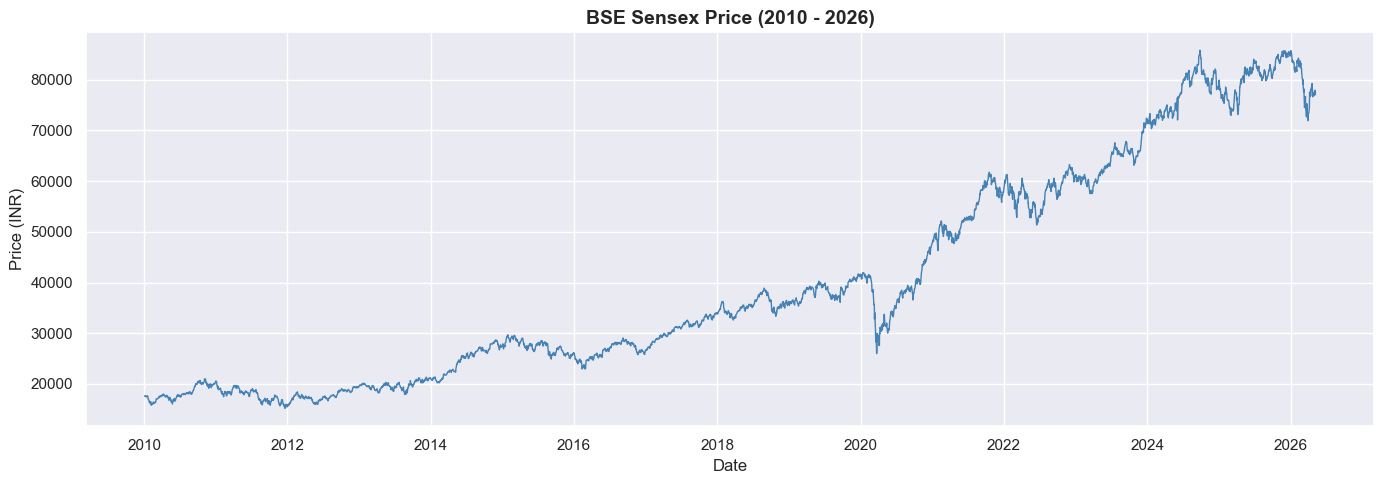

In [627]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df_sensex['Price'], color='steelblue', linewidth=1)
plt.title('BSE Sensex Price (2010 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

## *As we can see there is long term trend but no seasonality and intuitively see the data is not stationary*

### **NOW LETS CONFIRM IF OUR "PRICE" DATA IS STATIONARY OR NOT BU THE HELP OF AD-FULLER TEST**

In [628]:
sts.adfuller(df_sensex['Price'])

(np.float64(0.09982070950403851),
 np.float64(0.9660488509585018),
 29,
 4235,
 {'1%': np.float64(-3.4318950455880155),
  '5%': np.float64(-2.8622227159377456),
  '10%': np.float64(-2.5671334151787892)},
 np.float64(62905.73050839534))

### **As we can see that our p-value = 0.97 which is > 0.05 and test-statistic > table value for all confidence interval , we can conclude that our data is not stationary**

## **TO MAKE IT STATIONARY WE HAVE TO APPLY LOG RETURNS ON OUR DATA**

In [629]:
# Log Return
df_sensex['log_return'] = np.log(df_sensex['Price'] / df_sensex['Price'].shift(1))
df_sensex.head()

,Price,log_return
Date,,
2010-01-04,17558.73,NaN
2010-01-05,17686.24,0.007236
2010-01-06,17701.13,0.000842
2010-01-07,17615.72,-0.004837
2010-01-08,17540.29,-0.004291


### **Now we have to visualize our log return and check for stationarity of our log returns**

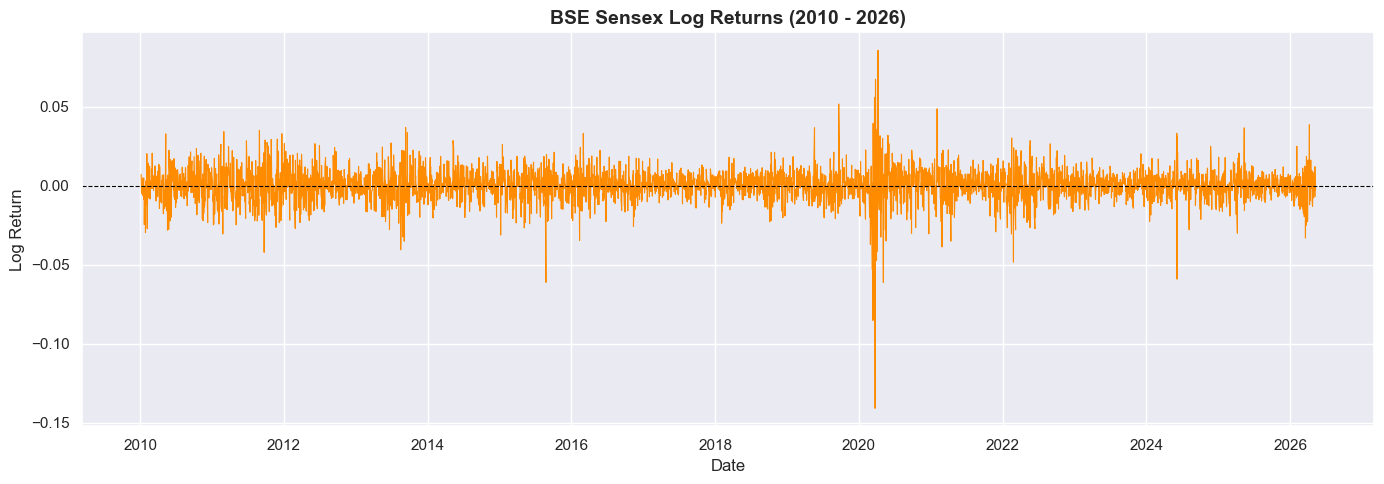

In [630]:
plt.figure(figsize=(14, 5))
plt.plot(df_sensex['log_return'], color='darkorange', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('BSE Sensex Log Returns (2010 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.tight_layout()
plt.show()

### **from here we can see that there is no trend and intutively see that the data is stationary, bnut for confirmation we have to apply AD-fuller test**

#### ***We can also confirm it by rolling mean graph then at the end we can check it by ad-fuller test***

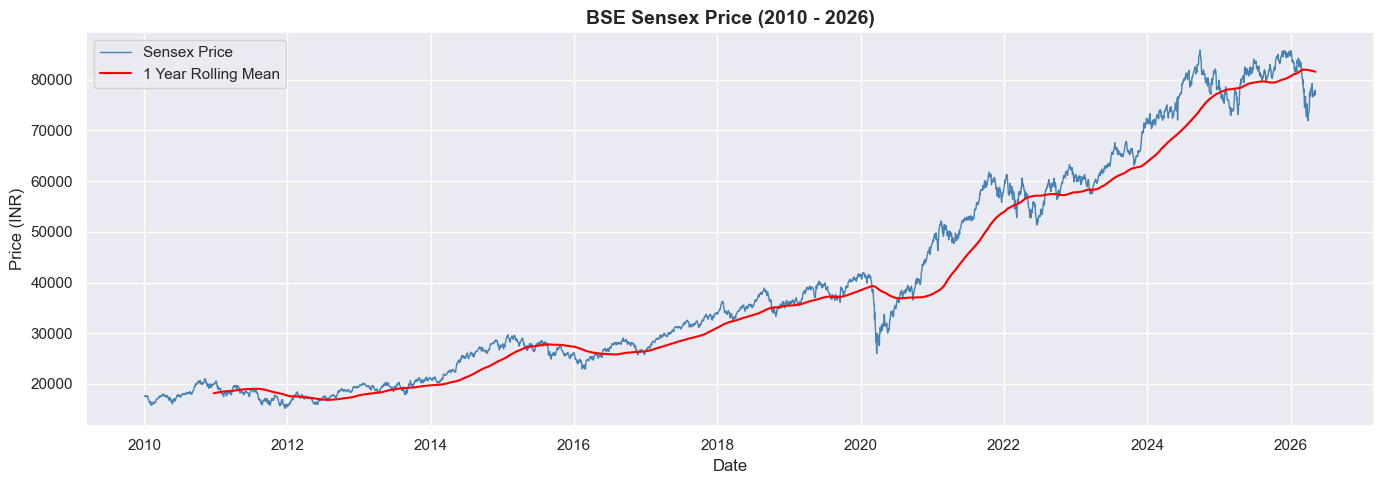

In [631]:
plt.figure(figsize=(14, 5))
plt.plot(df_sensex['Price'], color='steelblue', linewidth=1, label='Sensex Price')
plt.plot(df_sensex['Price'].rolling(252).mean(), color='red', linewidth=1.5, label='1 Year Rolling Mean')
plt.title('BSE Sensex Price (2010 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

### The rolling mean keeps shifting upward over time — which is a classic visual sign of non-stationarity. A stationary series would have a flat, constant rolling mean.

In [632]:
sts.adfuller(df_sensex['log_return'].dropna())

(np.float64(-19.477435542126088),
 0.0,
 10,
 4253,
 {'1%': np.float64(-3.431888502528218),
  '5%': np.float64(-2.862219825475238),
  '10%': np.float64(-2.567131876434272)},
 np.float64(-26919.826648625552))

## As we can see from here that p-value < 0.05 and test-statistic < table value ,so our data is stationary, now we can proceed furthur

### **---NOW WE HAVE TO SPLIKIT THE DATA IN 80-20 RATIO---**

In [633]:
sensex_train=df_sensex.iloc[:int(len(df_sensex)*0.8)]
sensex_test=df_sensex.iloc[int(len(df_sensex)*0.8):]

In [634]:
# shape of train and test data

print(f'Shape of training data -> {sensex_train.shape}')
print(f'Shape of testing data -> {sensex_test.shape}')

Shape of training data -> (3412, 2)
Shape of testing data -> (853, 2)


### *Visualizing the data*

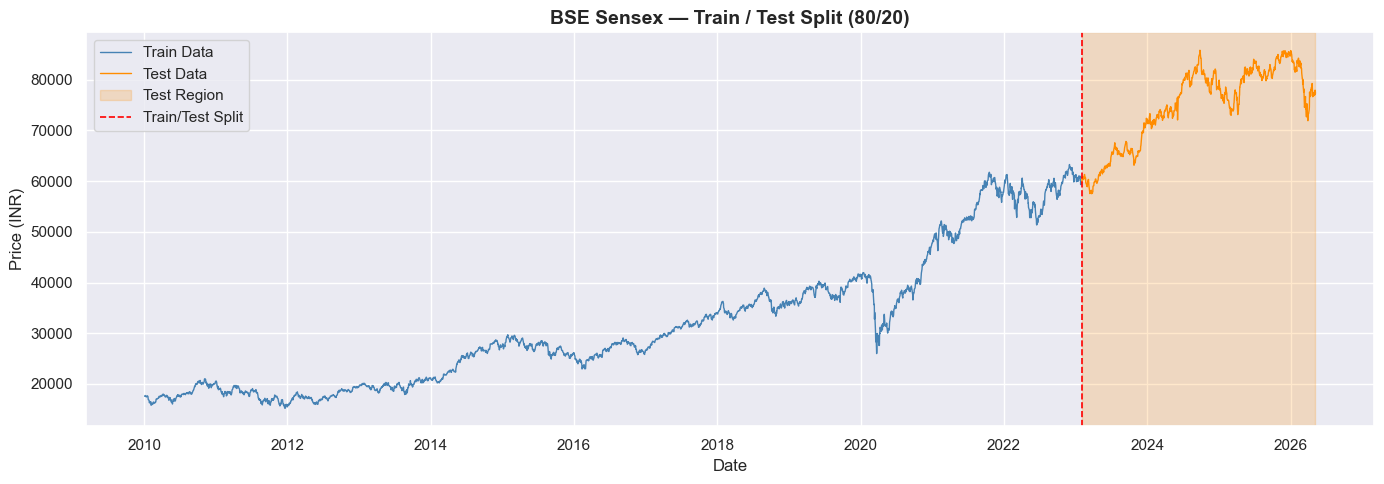

In [635]:
plt.figure(figsize=(14, 5))

# Plot train data
plt.plot(sensex_train.index, sensex_train['Price'], color='steelblue', linewidth=1, label='Train Data')

# Plot test data
plt.plot(sensex_test.index, sensex_test['Price'], color='darkorange', linewidth=1, label='Test Data')

# Shaded region for test data
plt.axvspan(sensex_test.index[0], sensex_test.index[-1], alpha=0.2, color='darkorange', label='Test Region')

# Split line
plt.axvline(sensex_test.index[0], color='red', linewidth=1.2, linestyle='--', label='Train/Test Split')

plt.title('BSE Sensex — Train / Test Split (80/20)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

## **NEXT**-- "We plot the ACF and PACF of log returns to:
1. Test whether Sensex follows a random walk
   (no autocorrelation = random walk = hard to predict)
2. Check if any significant correlation exists 
   between past and present returns
3. Determine the optimal p and q values 
   for our AR and MA models"

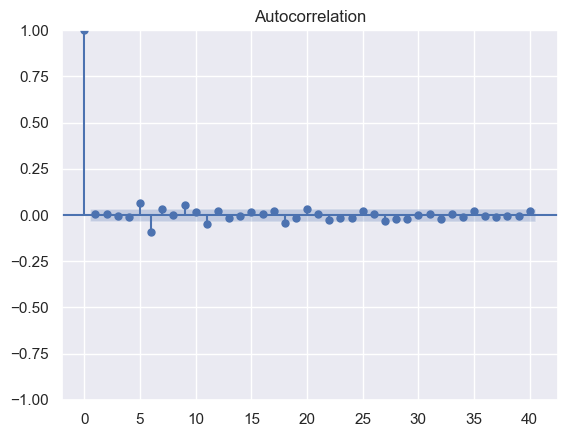

In [636]:
# Plotting ACF
sgt.plot_acf(sensex_train['log_return'].dropna(),lags=40);

"The ACF plot of Sensex log returns shows that 
most autocorrelations at all lags fall within 
the 95% confidence bands (blue region), indicating 
that the log returns are largely uncorrelated with 
their past values. This suggests that Sensex closely 
follows a random walk, meaning past returns have 
very little predictive power over future returns.
This also explains why AR and MA models 
will have limited forecasting ability on this data."

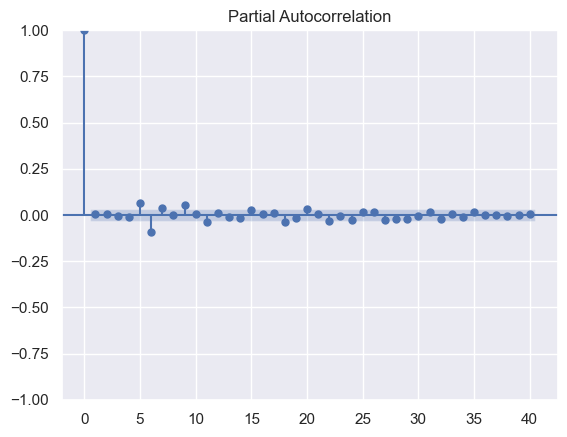

In [637]:
# Plotting PACF
sgt.plot_pacf(sensex_train['log_return'].dropna(),lags=40);

"The PACF plot also shows significant spikes at 
lag 5 and lag 6, indicating that after removing 
the effect of intermediate lags, there is still 
a direct relationship between current returns and 
returns from 5 and 6 days ago. Based on this, 
we select p = 6 as the order for our AR model."

## ***NOW LET'S PROCEED FURTHUR AND PROCEED WITH BASELINE MODELS***

"Before applying advanced time series models like 
AR and MA, we first establish baseline models. 
Baseline models are simple forecasting methods 
that require minimal assumptions and computation. 

They serve as a benchmark — any advanced model 
we build must perform better than these baselines 
to be considered useful. If our AR or MA model 
cannot beat a simple baseline, it means the model 
is not adding any value.

We apply the following 3 baseline models on the 
Sensex closing price:

1. Naive Model — assumes tomorrow's price equals 
   today's price

2. Simple Average Model — assumes tomorrow's price 
   equals the average of all past prices

3. Moving Average Model — assumes tomorrow's price 
   equals the average of the last n days

After forecasting, we evaluate each model using 
error metrics (MAE, RMSE, MAPE) and compare 
their performance."

## ***-------1.) NAIVE MODEL--------***

In [638]:
# Last value of train data
naive_forecast = sensex_test['Price'].copy()
naive_forecast[:] = sensex_train['Price'].iloc[-1]
sensex_test['naive_forecast'] = sensex_train['Price'].iloc[-1]
sensex_test.head()

,Price,log_return,naive_forecast
Date,,,
2023-02-01,59708.08,0.002653,59549.9
2023-02-02,59932.24,0.003747,59549.9
2023-02-03,60841.88,0.015064,59549.9
2023-02-06,60506.90,-0.005521,59549.9
2023-02-07,60286.04,-0.003657,59549.9


### **Now lets plot our data and visualize**

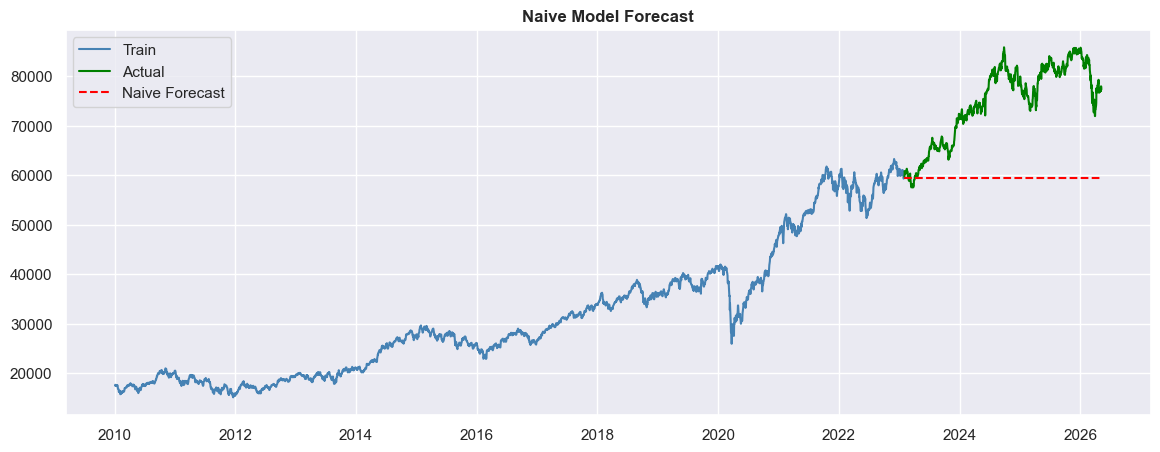

In [639]:
# Then plot
plt.figure(figsize=(14,5))
plt.plot(sensex_train['Price'], color='steelblue', label='Train')
plt.plot(sensex_test['Price'], color='green', label='Actual')
plt.plot(sensex_test['naive_forecast'], color='red', linestyle='--', label='Naive Forecast')
plt.title('Naive Model Forecast', fontweight='bold')
plt.legend()
plt.show()

## As we can see the naive model is far off from the test data , now we have to find the errors of naive model

In [640]:
# ERROR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
mae = mean_absolute_error(sensex_test['Price'], sensex_test['naive_forecast'])

# RMSE
rmse = np.sqrt(mean_squared_error(sensex_test['Price'], sensex_test['naive_forecast']))

# MAPE
mape = np.mean(np.abs((sensex_test['Price'] - sensex_test['naive_forecast']) / sensex_test['Price'])) * 100

print('=== Naive Model Errors ===')
print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

=== Naive Model Errors ===
MAE  : 15298.83
RMSE : 17110.46
MAPE : 19.54%


"We evaluate our models using three error metrics:

MAE tells us the average error in rupees — 
how far off our forecast is on a typical day.

RMSE tells us if our model is making large 
errors on some days — it penalizes big mistakes 
more than small ones.

MAPE tells us the error as a percentage — 
making it easy to compare across all models 
regardless of the price level."

In [641]:
# STORING RESULT FOR LATER COMPARISION
results = pd.DataFrame(columns=['Model', 'MAE', 'RMSE', 'MAPE'])
results.loc[0] = ['Naive', mae, rmse, mape]
print(results)

   Model           MAE         RMSE       MAPE
0  Naive  15298.834666  17110.45582  19.542711


## ***-------2.) SIMPLE AVERAGE MODEL--------***

In [642]:
# Simple Average Model
# Forecast = mean of all train prices
sensex_test['avg_forecast'] = sensex_train['Price'].mean()
sensex_test.head()

,Price,log_return,naive_forecast,avg_forecast
Date,,,,
2023-02-01,59708.08,0.002653,59549.9,31415.277254
2023-02-02,59932.24,0.003747,59549.9,31415.277254
2023-02-03,60841.88,0.015064,59549.9,31415.277254
2023-02-06,60506.90,-0.005521,59549.9,31415.277254
2023-02-07,60286.04,-0.003657,59549.9,31415.277254


### **Now lets plot our data and visualize**

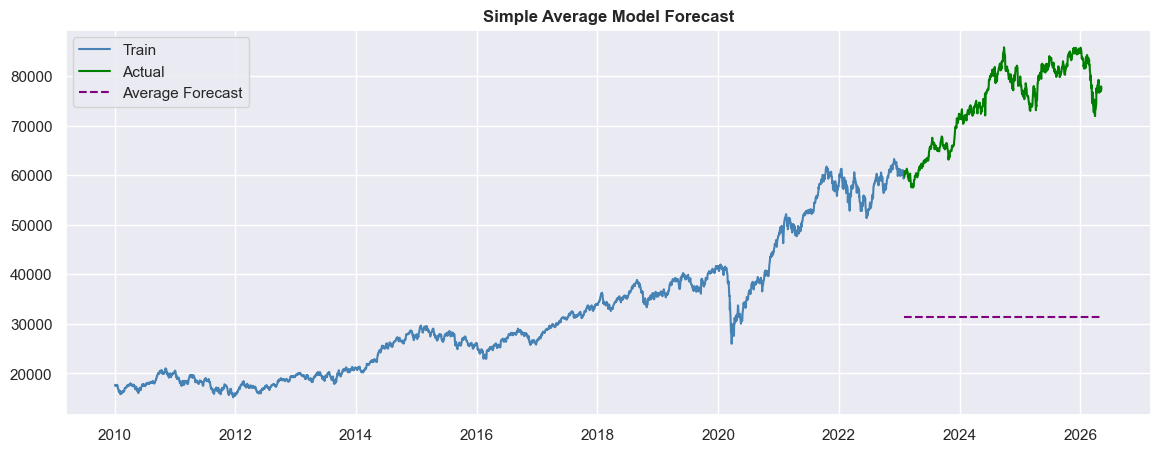

In [643]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(sensex_train['Price'], color='steelblue', label='Train')
plt.plot(sensex_test['Price'], color='green', label='Actual')
plt.plot(sensex_test['avg_forecast'], color='purple', linestyle='--', label='Average Forecast')
plt.title('Simple Average Model Forecast', fontweight='bold')
plt.legend()
plt.show()

## As we can see the naive model is far off from the test data , now we have to find the errors of naive model

In [644]:
# Error Metrics
mae  = mean_absolute_error(sensex_test['Price'], sensex_test['avg_forecast'])
rmse = np.sqrt(mean_squared_error(sensex_test['Price'], sensex_test['avg_forecast']))
mape = np.mean(np.abs((sensex_test['Price'] - sensex_test['avg_forecast']) / sensex_test['Price'])) * 100

print('=== Simple Average Model Errors ===')
print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

=== Simple Average Model Errors ===
MAE  : 43369.22
RMSE : 44063.18
MAPE : 57.50%


## As we can see from MAPE that this model is worse predictor than the previous one 

### **This proves that simple average is useless for trending data like Sensex**

In [645]:
# Add to results
results.loc[1] = ['Simple Average', mae, rmse, mape]
print(results)

            Model           MAE          RMSE       MAPE
0           Naive  15298.834666  17110.455820  19.542711
1  Simple Average  43369.222242  44063.183208  57.496675


### ***ALL THE GRAPH IN ONE GRAPH***

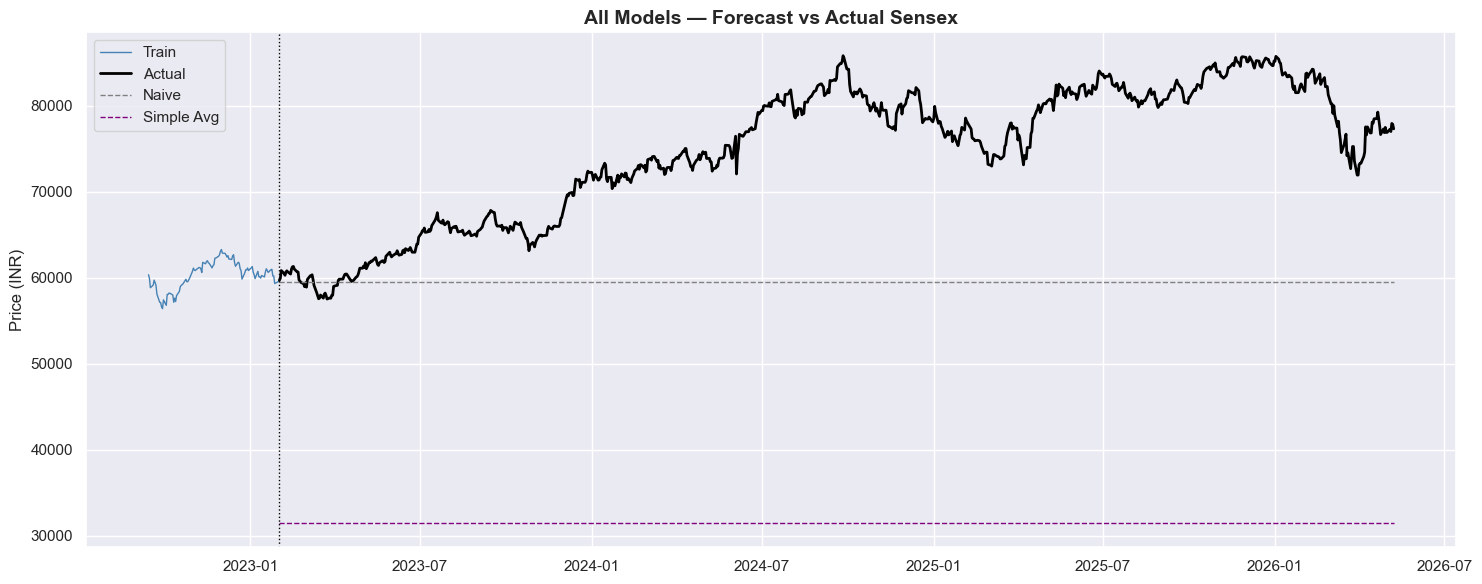

In [677]:
plt.figure(figsize=(15, 6))
plt.plot(sensex_train['Price'].iloc[-100:], 
         color='steelblue', label='Train', linewidth=1)
plt.plot(sensex_test['Price'], 
         color='black', linewidth=2, label='Actual')
plt.plot(sensex_test['naive_forecast'], 
         '--', color='gray', linewidth=1, label='Naive')
plt.plot(sensex_test['avg_forecast'],   
         '--', color='purple', linewidth=1, label='Simple Avg')
plt.axvline(sensex_test.index[0], color='black', 
            linestyle=':', linewidth=1)
plt.title('All Models — Forecast vs Actual Sensex', 
          fontsize=14, fontweight='bold')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## ***BAR GRAPH***

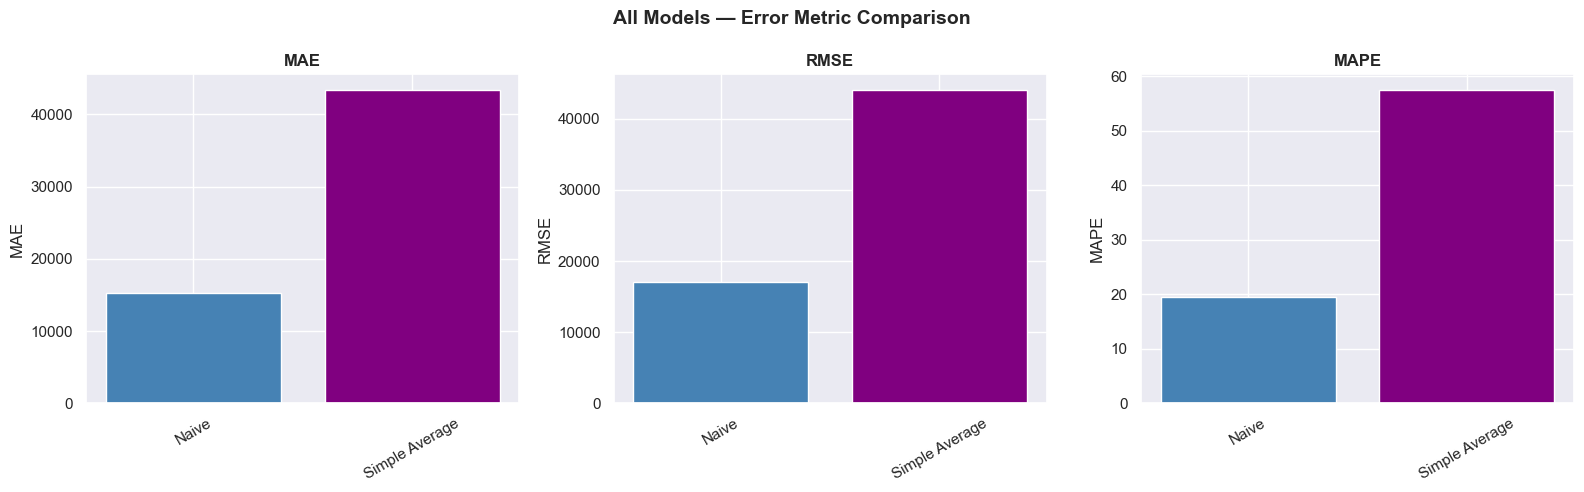

In [646]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(results['Model'], results[metric], 
           color=['steelblue','purple','darkorange','red','green'],
           edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('All Models — Error Metric Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ***-------3.)FORCASTING LAST 30 DAYS MEAN --------***

In [647]:
# Moving Average Model
# Forecast = average of last 30 days of train data
window = 30
sensex_test['30 days mean'] = sensex_train['Price'].rolling(window=window).mean().iloc[-1]
sensex_test.head()

,Price,log_return,naive_forecast,avg_forecast,30 days mean
Date,,,,,
2023-02-01,59708.08,0.002653,59549.9,31415.277254,60488.815333
2023-02-02,59932.24,0.003747,59549.9,31415.277254,60488.815333
2023-02-03,60841.88,0.015064,59549.9,31415.277254,60488.815333
2023-02-06,60506.90,-0.005521,59549.9,31415.277254,60488.815333
2023-02-07,60286.04,-0.003657,59549.9,31415.277254,60488.815333


### **Now lets plot our data and visualize**

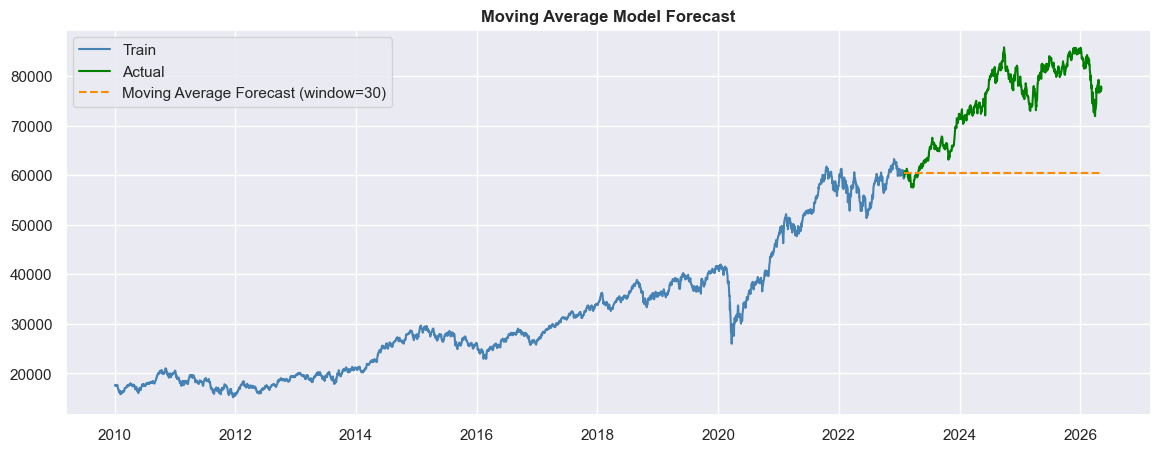

In [648]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(sensex_train['Price'], color='steelblue', label='Train')
plt.plot(sensex_test['Price'], color='green', label='Actual')
plt.plot(sensex_test['30 days mean'], color='darkorange', linestyle='--', label=f'Moving Average Forecast (window={window})')
plt.title('Moving Average Model Forecast', fontweight='bold')
plt.legend()
plt.show()

## As we can see it better than the previous two models, now lets proceed and find the error

In [649]:
# Error Metrics
mae  = mean_absolute_error(sensex_test['Price'], sensex_test['30 days mean'])
rmse = np.sqrt(mean_squared_error(sensex_test['Price'], sensex_test['30 days mean']))
mape = np.mean(np.abs((sensex_test['Price'] - sensex_test['30 days mean']) / sensex_test['Price'])) * 100
print('=== Moving Average Model Errors ===')
print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

=== Moving Average Model Errors ===
MAE  : 14442.16
RMSE : 16280.09
MAPE : 18.41%


Here the MAPE is less that the above models but far from good predictor so now we have to proceed with advance model 

In [650]:
# Add to results
results.loc[2] = ['30 days mean', mae, rmse, mape]
print(results)

            Model           MAE          RMSE       MAPE
0           Naive  15298.834666  17110.455820  19.542711
1  Simple Average  43369.222242  44063.183208  57.496675
2    30 days mean  14442.163686  16280.087907  18.412019


### ***ALL THE DATA IN ONE GRAPH***

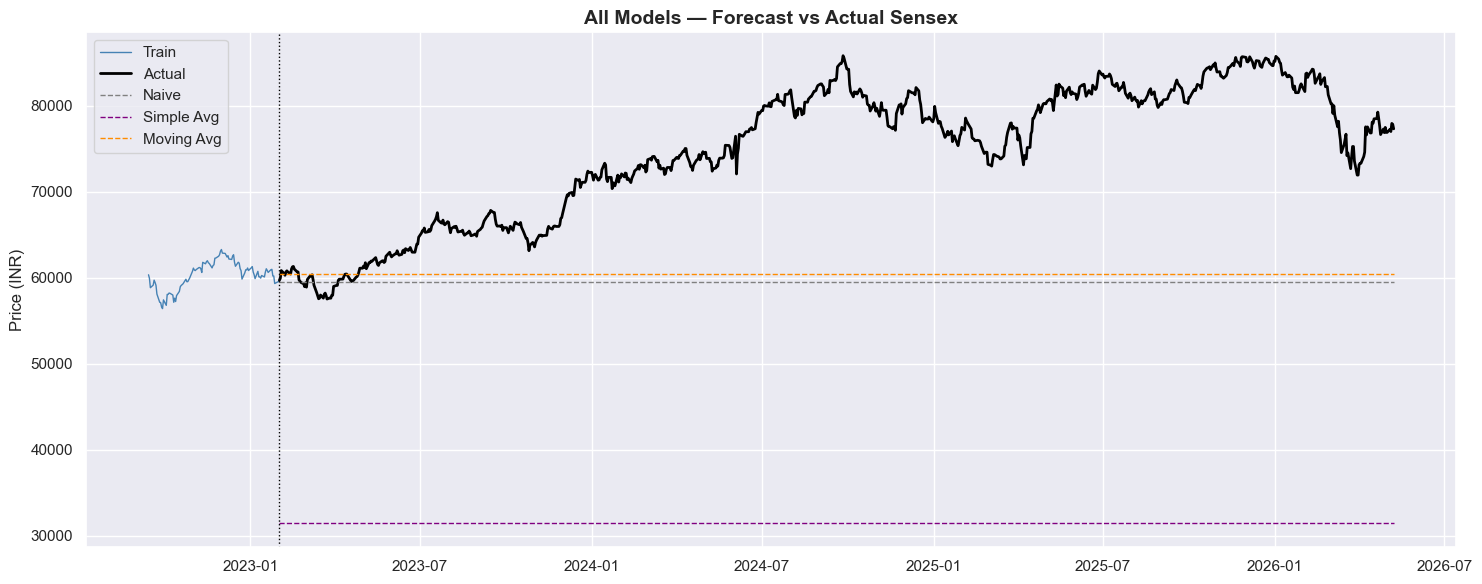

In [678]:
plt.figure(figsize=(15, 6))
plt.plot(sensex_train['Price'].iloc[-100:], 
         color='steelblue', label='Train', linewidth=1)
plt.plot(sensex_test['Price'], 
         color='black', linewidth=2, label='Actual')
plt.plot(sensex_test['naive_forecast'], 
         '--', color='gray', linewidth=1, label='Naive')
plt.plot(sensex_test['avg_forecast'],   
         '--', color='purple', linewidth=1, label='Simple Avg')
plt.plot(sensex_test['30 days mean'],    
         '--', color='darkorange', linewidth=1, label='Moving Avg')
plt.axvline(sensex_test.index[0], color='black', 
            linestyle=':', linewidth=1)
plt.title('All Models — Forecast vs Actual Sensex', 
          fontsize=14, fontweight='bold')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## ***BAR GRAPH***

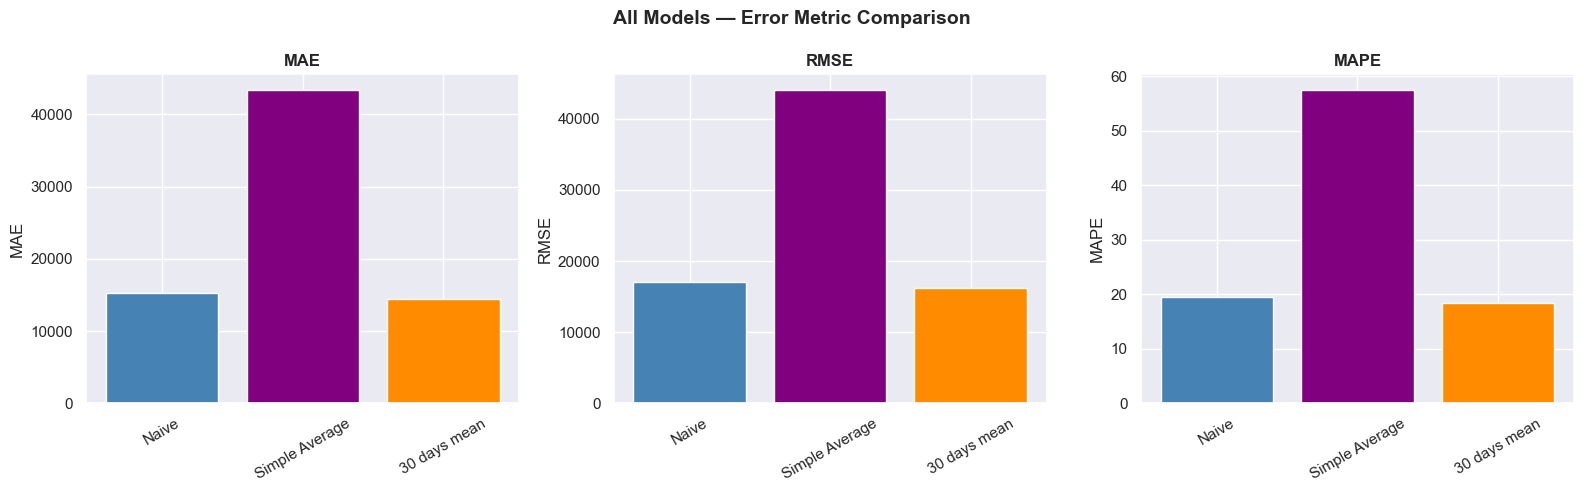

In [651]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(results['Model'], results[metric], 
           color=['steelblue','purple','darkorange','red','green'],
           edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('All Models — Error Metric Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **ADVANCED MODELS**

## ***-------4.)AR model --------***

"After establishing our baseline models, we now 
apply the AR (AutoRegressive) model.

An AR model predicts future values using a 
linear combination of its own past values.
The equation is:

y(t) = c + φ1*y(t-1) + φ2*y(t-2) + ... + φp*y(t-p) + ε

Where:
y(t)      = current value we want to predict
c         = constant
φ         = coefficients (weights given to past values)
y(t-1)    = value from 1 period ago
p         = number of past values used (order)
ε         = error term

The key parameter is p (order) which tells the 
model how many past values to look at.

From our PACF plot we observed significant spikes 
at lag 5 and lag 6, therefore we will use p = 6 
for our AR model.

Important: AR model requires stationary data, 
which is why we fit it on log returns instead 
of raw prices. After forecasting log returns 
we convert them back to prices for comparison."

#### **First we have to find the order of the AR model then we can proceed for that we have to look at the PACF graph again**

### ***Why do we use PACF for AR order and ACF for MA order?***

"A common question is — why do we look at the 
PACF graph to find the order of AR model and 
not the ACF graph?

The answer lies in what each model uses for 
prediction and what each graph measures.

The AR model predicts future values using past 
actual values of the series. We need to find 
the direct relationship between current value 
and each past value. PACF measures exactly this 
— it shows the pure direct correlation between 
current and past values by removing the effect 
of all intermediate lags. So PACF tells us 
exactly at which lag the direct effect stops, 
and that becomes our AR order (p).

If we used ACF for AR order, we would get a 
wrong answer because ACF includes both direct 
and indirect effects mixed together, which would 
overestimate the number of lags needed.

Similarly the MA model predicts future values 
using past errors. ACF measures the total 
correlation including all indirect effects, 
which matches exactly how MA model works. 
So ACF is used to find MA order (q).

In simple terms:
PACF → direct effect only → AR model
ACF  → total effect       → MA model"

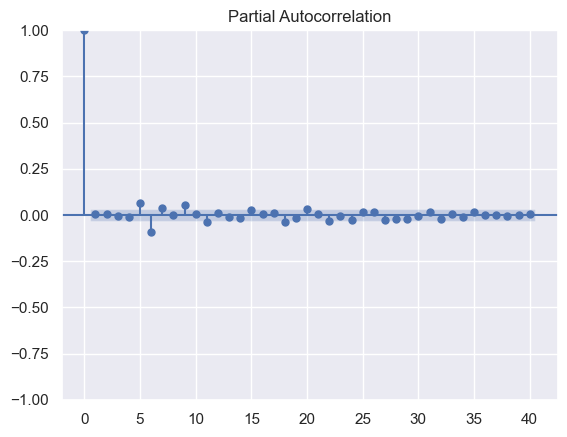

In [652]:
# Plotting PACF
sgt.plot_pacf(sensex_train['log_return'].dropna(),lags=40);

#### ***"From the PACF plot we can observe significant spikes at lag 5 and lag 6, which initially suggests that AR(5) or AR(6) could be the appropriate order for our AR model.***

However we cannot rely on the PACF plot alone 
to select the final order because:

1. PACF can sometimes show false significant 
   spikes due to randomness in the data

2. We need statistical confirmation that adding 
   each lag is actually improving the model 
   significantly

Therefore we will formally determine the best 
AR order by:

1. Fitting AR models from AR(1) to AR(6) 
   one by one

2. Checking AIC and BIC at each step
   → Lower AIC/BIC = better model

3. Applying the LLR (Log Likelihood Ratio) test 
   at each step to check if adding a new lag 
   significantly improves the model
   → p-value < 0.05 = significant improvement
   → p-value > 0.05 = no significant improvement

The model where LLR test becomes insignificant 
(p > 0.05) will be our final AR order."

In [653]:
## LLR test
def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))
    p = chi2.sf(LR, DF).round(3)
    return p

In [654]:
log_ret = sensex_train['log_return'].dropna()

# AR(1)
mod1 = ARIMA(log_ret, order=(1,0,0))
mod1_fitted = mod1.fit()
print('=== AR(1) ===')
print(f'AIC : {mod1_fitted.aic:.4f}')
print(f'BIC : {mod1_fitted.bic:.4f}')
print(mod1_fitted.summary())

=== AR(1) ===
AIC : -21320.9066
BIC : -21302.5024
                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 3411
Model:                 ARIMA(1, 0, 0)   Log Likelihood               10663.453
Date:                Sun, 10 May 2026   AIC                         -21320.907
Time:                        15:10:45   BIC                         -21302.502
Sample:                    01-05-2010   HQIC                        -21314.330
                         - 01-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.899      0.058   -1.14e-05       0.001
ar.L1          0.0079      0.010      0.792      0.428      -0.012       0.027
si

In [655]:
log_ret = sensex_train['log_return'].dropna()

# AR(2)
mod2 = ARIMA(log_ret, order=(2,0,0))
mod1_fitted = mod2.fit()
print('=== AR(2) ===')
print(f'AIC : {mod1_fitted.aic:.4f}')
print(f'BIC : {mod1_fitted.bic:.4f}')
print(mod1_fitted.summary())

=== AR(2) ===
AIC : -21319.0740
BIC : -21294.5350
                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 3411
Model:                 ARIMA(2, 0, 0)   Log Likelihood               10663.537
Date:                Sun, 10 May 2026   AIC                         -21319.074
Time:                        15:10:45   BIC                         -21294.535
Sample:                    01-05-2010   HQIC                        -21310.305
                         - 01-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.839      0.066   -2.35e-05       0.001
ar.L1          0.0078      0.010      0.756      0.450      -0.012       0.028
ar

In [656]:
# Applying LLR test and comparing AR(1) and AR(2)
print(LLR_test(mod1,mod2))

0.682


#### ***when adding more lags, the LLR test gives a  p-value of 0.682 which is greater than 0.05. This means the improvement is not statistically significant Therefore we prefer the simpler model following the principle of parsimony — always choose the simplest model that explains the data adequately.***

### ***FITTING AR(1) MODEL***

In [657]:
# Fit final AR(1) model
log_ret = sensex_train['log_return'].dropna()

final_ar = ARIMA(log_ret, order=(1,0,0)).fit()
print(final_ar.summary())

                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 3411
Model:                 ARIMA(1, 0, 0)   Log Likelihood               10663.453
Date:                Sun, 10 May 2026   AIC                         -21320.907
Time:                        15:10:46   BIC                         -21302.502
Sample:                    01-05-2010   HQIC                        -21314.330
                         - 01-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.899      0.058   -1.14e-05       0.001
ar.L1          0.0079      0.010      0.792      0.428      -0.012       0.027
sigma2         0.0001   1.08e-06    103.951      0.0

### **Forecast and convert back to prices:**

In [658]:
# Forecast log returns for test period
forecast_log_ret = final_ar.forecast(steps=len(sensex_test))

# Convert log returns back to prices
last_train_price = sensex_train['Price'].iloc[-1]
ar_prices = []

for lr in forecast_log_ret:
    last_train_price = last_train_price * np.exp(lr)
    ar_prices.append(last_train_price)

# Store in test dataframe
sensex_test['ar_forecast'] = ar_prices

### **Now lets plot our data and visualize**

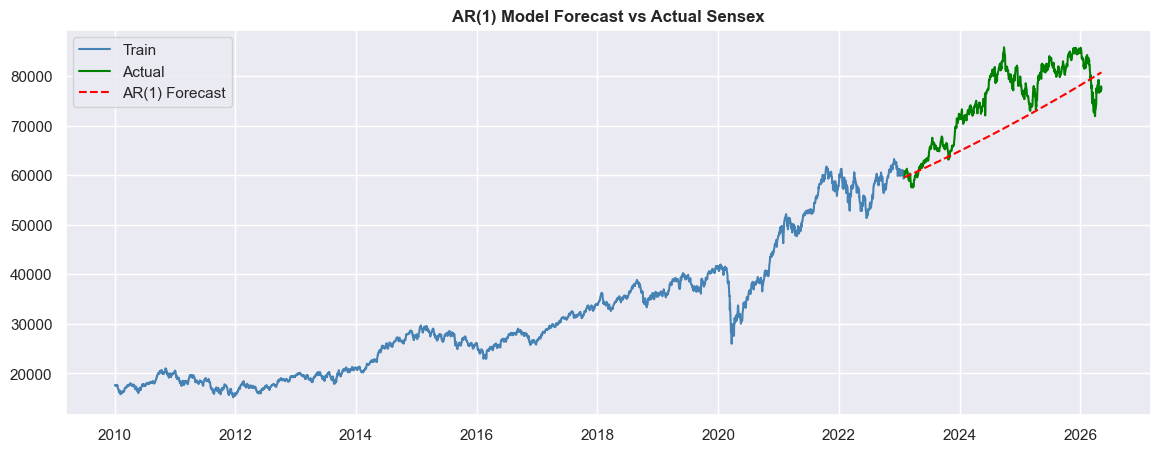

In [659]:
plt.figure(figsize=(14,5))
plt.plot(sensex_train['Price'], color='steelblue', label='Train')
plt.plot(sensex_test['Price'], color='green', label='Actual')
plt.plot(sensex_test['ar_forecast'], color='red', 
         linestyle='--', label='AR(1) Forecast')
plt.title('AR(1) Model Forecast vs Actual Sensex', fontweight='bold')
plt.legend()
plt.show()

## As we can see it better than the previous baseline models, now lets proceed and find the error.

In [660]:
mae  = mean_absolute_error(sensex_test['Price'], sensex_test['ar_forecast'])
rmse = np.sqrt(mean_squared_error(sensex_test['Price'], sensex_test['ar_forecast']))
mape = np.mean(np.abs((sensex_test['Price'] - sensex_test['ar_forecast']) / sensex_test['Price'])) * 100

print('=== AR(1) Model Errors ===')
print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

=== AR(1) Model Errors ===
MAE  : 5700.71
RMSE : 6663.51
MAPE : 7.35%


Here the MAPE is less that the above models but not enough good predictor so now we have to proceed with MA model

In [ ]:
results.loc[3] = ['AR(1)', mae, rmse, mape]

### ***ALL THE DATA IN ONE GRAPH***

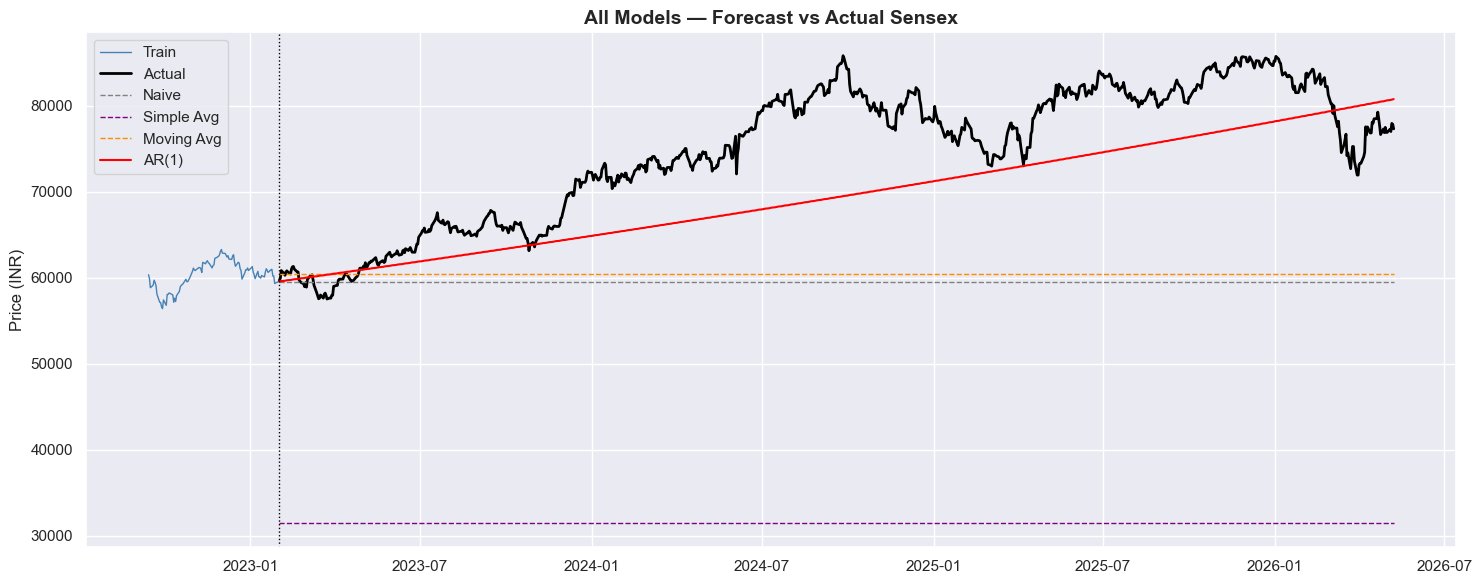

In [679]:
plt.figure(figsize=(15, 6))
plt.plot(sensex_train['Price'].iloc[-100:], 
         color='steelblue', label='Train', linewidth=1)
plt.plot(sensex_test['Price'], 
         color='black', linewidth=2, label='Actual')
plt.plot(sensex_test['naive_forecast'], 
         '--', color='gray', linewidth=1, label='Naive')
plt.plot(sensex_test['avg_forecast'],   
         '--', color='purple', linewidth=1, label='Simple Avg')
plt.plot(sensex_test['30 days mean'],    
         '--', color='darkorange', linewidth=1, label='Moving Avg')
plt.plot(sensex_test['ar_forecast'],    
         '-', color='red', linewidth=1.5, label='AR(1)')
plt.axvline(sensex_test.index[0], color='black', 
            linestyle=':', linewidth=1)
plt.title('All Models — Forecast vs Actual Sensex', 
          fontsize=14, fontweight='bold')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## ***BAR GRAPH***

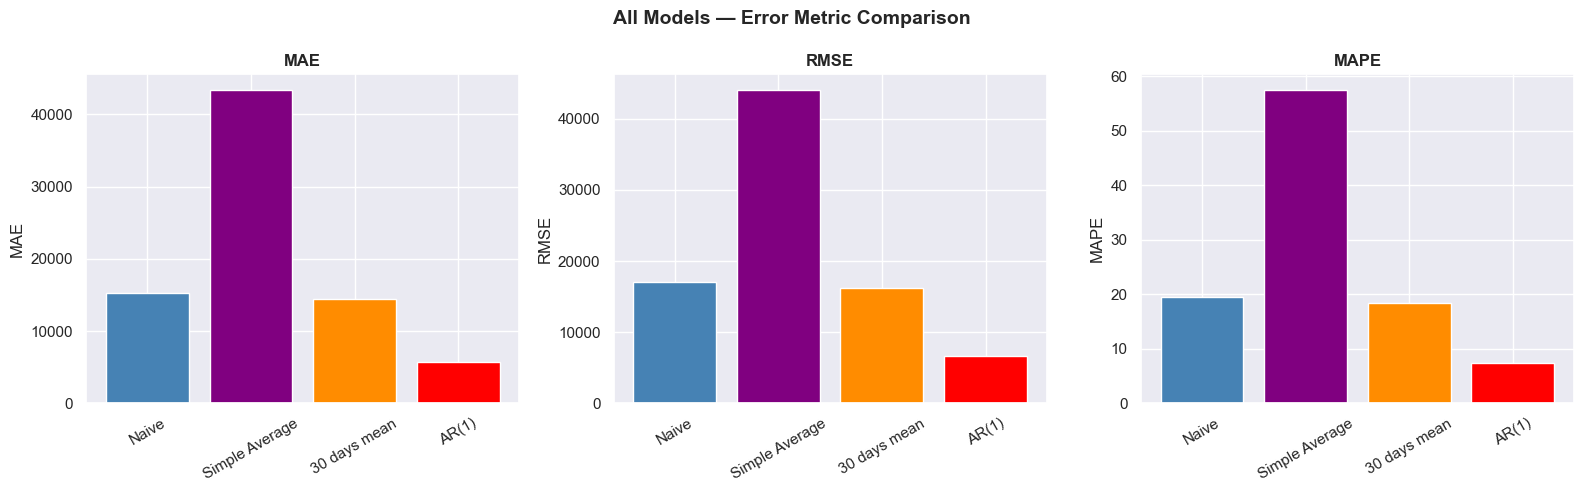

In [662]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(results['Model'], results[metric], 
           color=['steelblue','purple','darkorange','red','green'],
           edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('All Models — Error Metric Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ***-------5.)MA(moving average) model --------***

"After fitting the AR model, we now apply the 
MA (Moving Average) model.

Unlike the AR model which uses past actual values, 
the MA model predicts future values using past 
forecast errors (residuals).

The equation is:

y(t) = μ + ε(t) + θ1*ε(t-1) + θ2*ε(t-2) + ... + θq*ε(t-q)

Where:
y(t)    = current value we want to predict
μ       = mean of the series
ε(t)    = current error
θ       = coefficients (weights given to past errors)
q       = number of past errors used (order)

The key parameter is q (order) which tells the 
model how many past errors to look at.

From our ACF plot we observed significant spikes 
at lag 5 and lag 6, which suggests q = 5 or 6.

Just like AR model, we will formally confirm 
the best order by:

1. Fitting MA models from MA(1) to MA(6)
2. Checking AIC and BIC at each step
3. Applying LLR test at each step

MA model is fitted on log returns (stationary data) 
and predictions are converted back to prices 
for final comparison."

### **firstly we have to see the PACF graph and see what can we take out of that**

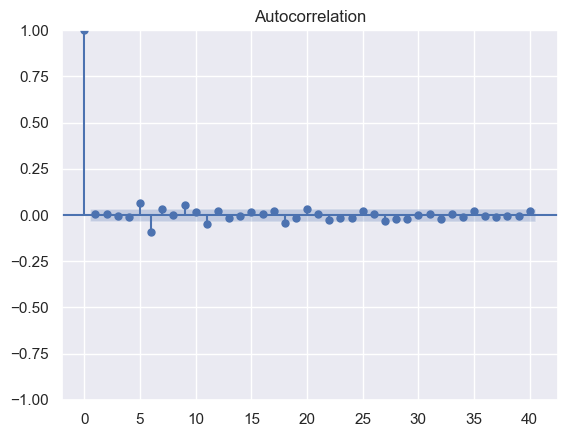

In [663]:
# Plotting ACF
sgt.plot_acf(sensex_train['log_return'].dropna(),lags=40);

### "From the ACF plot we observe significant spikes at lag 5 and lag 6, which suggests that MA(5) or MA(6) could be the appropriate order for our MA model. However just like the AR model,we cannot rely on ACF plot alone. We will formally confirm the best order using AIC, BIC and LLR test."

In [664]:
log_ret = sensex_train['log_return'].dropna()

# MA(1)
mod1_ma = ARIMA(log_ret, order=(0,0,1))
mod1_ma_fitted = mod1_ma.fit()
print('=== MA(1) ===')
print(f'AIC : {mod1_ma_fitted.aic:.4f}')
print(f'BIC : {mod1_ma_fitted.bic:.4f}')

=== MA(1) ===
AIC : -21320.9024
BIC : -21302.4981


In [665]:
# MA(2)
mod2_ma = ARIMA(log_ret, order=(0,0,2))
mod2_ma_fitted = mod2_ma.fit()
print('=== MA(2) ===')
print(f'AIC : {mod2_ma_fitted.aic:.4f}')
print(f'BIC : {mod2_ma_fitted.bic:.4f}')

# LLR test MA(1) vs MA(2)
print(f'\nLLR Test MA(1) vs MA(2) : {LLR_test(mod1_ma, mod2_ma)}')

=== MA(2) ===
AIC : -21319.0769
BIC : -21294.5379

LLR Test MA(1) vs MA(2) : 0.676


#### ***"The LLR test comparing MA(1) and MA(2) gives a p-value of 0.676 which is greater than 0.05. This means adding a second lag does not significantly improve the model. Therefore MA(1) is selected as our final MA model, following the principle of parsimony — always choose the simplest model that adequately explains the data."***

## ***fit MA(1) and forecast:***

In [666]:
# Fit final MA(1) model
final_ma = ARIMA(log_ret, order=(0,0,1)).fit()
print(final_ma.summary())

                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 3411
Model:                 ARIMA(0, 0, 1)   Log Likelihood               10663.451
Date:                Sun, 10 May 2026   AIC                         -21320.902
Time:                        15:10:53   BIC                         -21302.498
Sample:                    01-05-2010   HQIC                        -21314.325
                         - 01-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.891      0.059   -1.29e-05       0.001
ma.L1          0.0079      0.010      0.795      0.427      -0.012       0.027
sigma2         0.0001   1.08e-06    104.097      0.0

In [667]:
# Forecast log returns
forecast_log_ret_ma = final_ma.forecast(steps=len(sensex_test))

In [668]:
# Convert back to prices
last_train_price = sensex_train['Price'].iloc[-1]
ma_prices = []

for lr in forecast_log_ret_ma:
    last_train_price = last_train_price * np.exp(lr)
    ma_prices.append(last_train_price)
# Store in test dataframe
sensex_test['ma_forecast'] = ma_prices

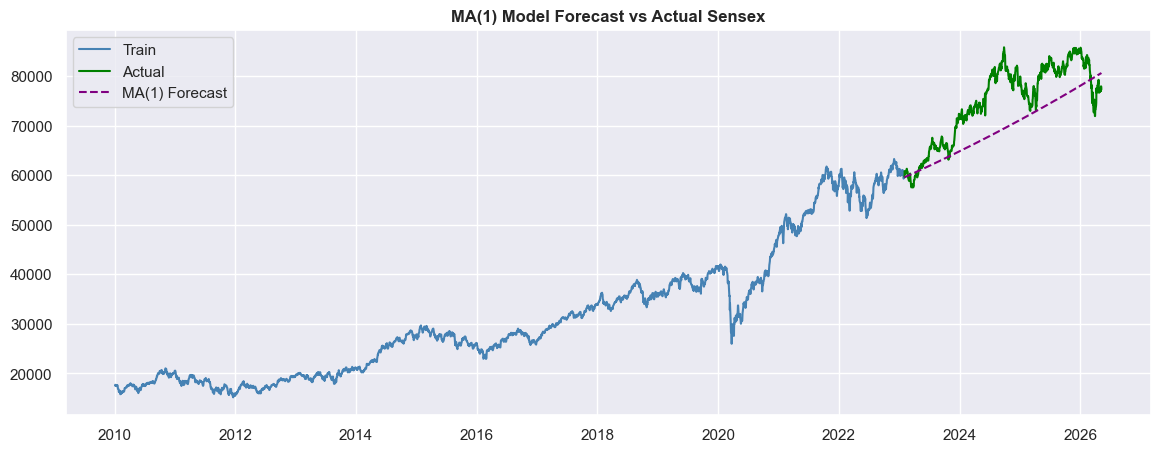

In [669]:
# Plot
plt.figure(figsize=(14,5))
plt.plot(sensex_train['Price'], color='steelblue', label='Train')
plt.plot(sensex_test['Price'], color='green', label='Actual')
plt.plot(sensex_test['ma_forecast'], color='purple',
         linestyle='--', label='MA(1) Forecast')
plt.title('MA(1) Model Forecast vs Actual Sensex', fontweight='bold')
plt.legend()
plt.show()

In [670]:
# Errors
mae  = mean_absolute_error(sensex_test['Price'], sensex_test['ma_forecast'])
rmse = np.sqrt(mean_squared_error(sensex_test['Price'], sensex_test['ma_forecast']))
mape = np.mean(np.abs((sensex_test['Price'] - sensex_test['ma_forecast']) / sensex_test['Price'])) * 100

print('=== MA(1) Model Errors ===')
print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'MAPE : {mape:.2f}%')

=== MA(1) Model Errors ===
MAE  : 5743.89
RMSE : 6709.55
MAPE : 7.40%


In [671]:
results.loc[4] = ['MA(1)', mae, rmse, mape]

Here the MAPE is less that the baseline models but not better than the AR model and also not the good predictor so we proceed with more advanced models

"We use a simple one time forecast approach 
where the model is trained once on the entire 
training data and then used to forecast all 
test period values at once. A more advanced 
approach would be walk forward validation 
where the model is retrained as each new data 
point becomes available, better simulating 
real world forecasting conditions."

## ***RESULT TABLE***

In [672]:
# Print final results table
print('='*55)
print('        FINAL MODEL COMPARISON')
print('='*55)
print(results.to_string(index=False))
print()
print(f"Best model by MAPE : {results.loc[results['MAPE'].idxmin(), 'Model']}")

        FINAL MODEL COMPARISON
         Model          MAE         RMSE      MAPE
         Naive 15298.834666 17110.455820 19.542711
Simple Average 43369.222242 44063.183208 57.496675
  30 days mean 14442.163686 16280.087907 18.412019
         AR(1)  5700.712279  6663.507894  7.348532
         MA(1)  5743.886945  6709.545942  7.402781

Best model by MAPE : AR(1)


## ***BAR CHART COMPARISON***

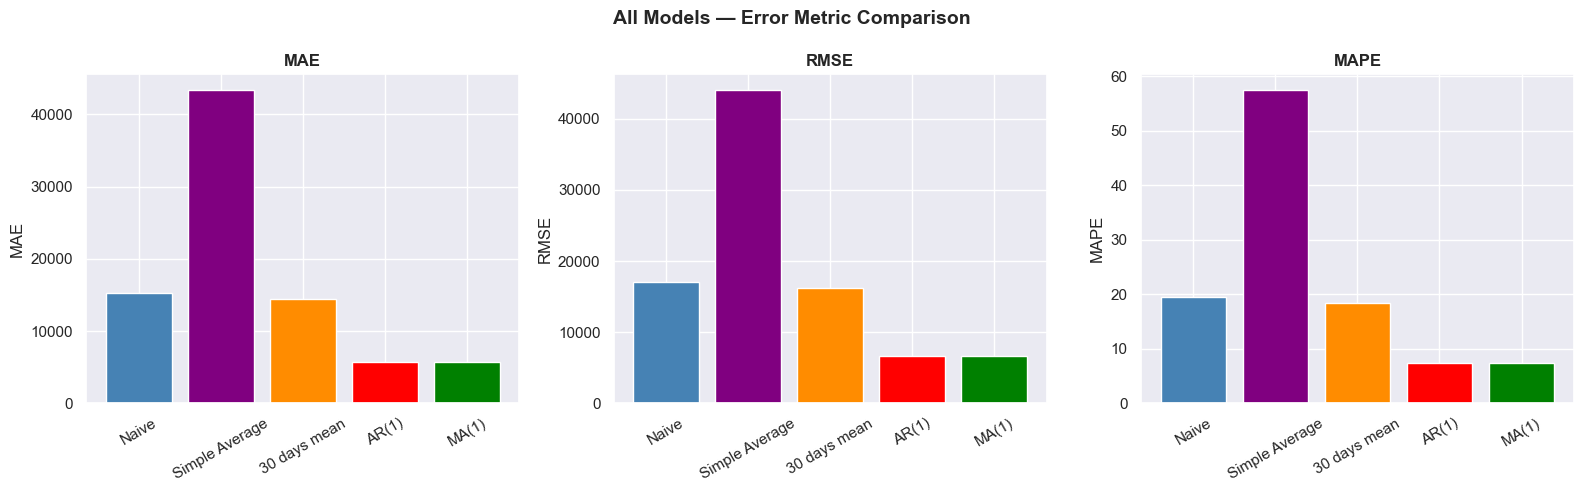

In [673]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    ax.bar(results['Model'], results[metric], 
           color=['steelblue','purple','darkorange','red','green'],
           edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('All Models — Error Metric Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### ***All Forecasts on One Graph*** 

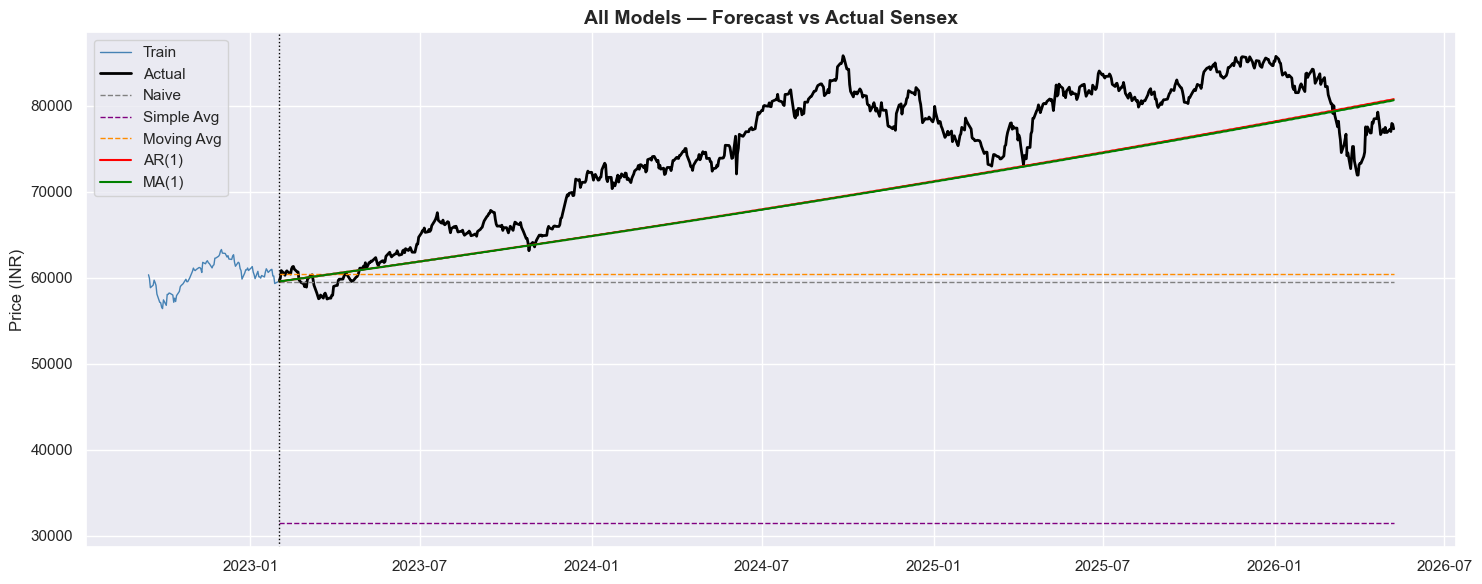

In [676]:
plt.figure(figsize=(15, 6))
plt.plot(sensex_train['Price'].iloc[-100:], 
         color='steelblue', label='Train', linewidth=1)
plt.plot(sensex_test['Price'], 
         color='black', linewidth=2, label='Actual')
plt.plot(sensex_test['naive_forecast'], 
         '--', color='gray', linewidth=1, label='Naive')
plt.plot(sensex_test['avg_forecast'],   
         '--', color='purple', linewidth=1, label='Simple Avg')
plt.plot(sensex_test['30 days mean'],    
         '--', color='darkorange', linewidth=1, label='Moving Avg')
plt.plot(sensex_test['ar_forecast'],    
         '-', color='red', linewidth=1.5, label='AR(1)')
plt.plot(sensex_test['ma_forecast'],    
         '-', color='green', linewidth=1.5, label='MA(1)')

plt.axvline(sensex_test.index[0], color='black', 
            linestyle=':', linewidth=1)
plt.title('All Models — Forecast vs Actual Sensex', 
          fontsize=14, fontweight='bold')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()